<a href="https://colab.research.google.com/github/jzhen3/Employee-Access-Recommender/blob/main/word_embedding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# word2vec demo with Gensim

In [ ]:
import numpy as np

# Get the interactive Tools for Matplotlib
%matplotlib notebook
import matplotlib.pyplot as plt
plt.style.use('ggplot')

from sklearn.decomposition import PCA

from gensim.test.utils import datapath, get_tmpfile
from gensim.models import KeyedVectors
from gensim.scripts.glove2word2vec import glove2word2vec

You can download the pretrained word vectors at:
https://github.com/eyaler/word2vec-slim/blob/master/GoogleNews-vectors-negative300-SLIM.bin.gz
Or, you can download the data using the wget command:


In [ ]:
!wget https://media.githubusercontent.com/media/eyaler/word2vec-slim/master/GoogleNews-vectors-negative300-SLIM.bin.gz

--2024-02-07 21:25:54--  https://media.githubusercontent.com/media/eyaler/word2vec-slim/master/GoogleNews-vectors-negative300-SLIM.bin.gz
Resolving media.githubusercontent.com (media.githubusercontent.com)... 185.199.111.133, 185.199.110.133, 185.199.109.133, ...
Connecting to media.githubusercontent.com (media.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 276467217 (264M) [application/octet-stream]
Saving to: ‘GoogleNews-vectors-negative300-SLIM.bin.gz’

GoogleNews-vectors- 100%[===================>] 263.66M   207MB/s    in 1.3s    

2024-02-07 21:25:55 (207 MB/s) - ‘GoogleNews-vectors-negative300-SLIM.bin.gz’ saved [276467217/276467217]



In [ ]:
model = KeyedVectors.load_word2vec_format('./GoogleNews-vectors-negative300-SLIM.bin.gz', binary=True)

In [ ]:
model['learning']

array([-0.03533386,  0.05934526, -0.02518269,  0.04704674,  0.0439233 ,
        0.01737411,  0.02196165,  0.01756932, -0.02459705, -0.02371858,
        0.11244366,  0.03240564, -0.06442085, -0.02557312,  0.01805736,
       -0.02401141, -0.07222943,  0.08199017,  0.03240564, -0.06637299,
       -0.01010236,  0.07027729, -0.0006863 ,  0.08550403, -0.00478276,
       -0.06754428,  0.00907748, -0.03709079, -0.01073681, -0.03767643,
       -0.02615877,  0.02811091, -0.02811091, -0.01961908, -0.00985834,
       -0.06832514,  0.00339186, -0.02850134,  0.03787165, -0.07144857,
        0.02850134,  0.02118079, -0.00639328, -0.02498748, -0.02108319,
       -0.03630993,  0.04470416,  0.08979876, -0.06949643,  0.06832514,
       -0.00187894,  0.05505054, -0.04275202,  0.00990715,  0.07418158,
        0.16241862, -0.01395785, -0.0730103 ,  0.03962858, -0.069106  ,
        0.01215211,  0.02713484,  0.03748122, -0.11947139,  0.00346506,
        0.03650515, -0.06520171, -0.02303533,  0.03338171, -0.02

## Find most similar words

In [ ]:
model.most_similar('flight')

[('flights', 0.7215829491615295),
 ('plane', 0.6747332811355591),
 ('Flight', 0.6653609275817871),
 ('airplane', 0.628650963306427),
 ('takeoff', 0.5987354516983032),
 ('jet', 0.5873551964759827),
 ('airline', 0.5678630471229553),
 ('Flights', 0.5677327513694763),
 ('airliner', 0.5646218061447144),
 ('aircraft', 0.5610387325286865)]

In [ ]:
model.most_similar('banana')

[('bananas', 0.7523776292800903),
 ('pineapple', 0.6587538719177246),
 ('mango', 0.6365212202072144),
 ('pineapples', 0.6313879489898682),
 ('papaya', 0.6063666343688965),
 ('coconut', 0.6035483479499817),
 ('potato', 0.5747568607330322),
 ('melon', 0.5625775456428528),
 ('cashew', 0.562165379524231),
 ('tomato', 0.5590205788612366)]

In [ ]:
model.most_similar('obama')

[('mccain', 0.7319012880325317),
 ('hillary', 0.7284600138664246),
 ('palin', 0.7043113708496094),
 ('clinton', 0.6934449672698975),
 ('barack', 0.672263503074646),
 ('gop', 0.669115424156189),
 ('biden', 0.6689552664756775),
 ('dems', 0.6643067598342896),
 ('BHO', 0.6569867730140686),
 ('reid', 0.6534700393676758)]

## Word analogy

In [ ]:
result = model.most_similar(positive=['woman', 'king'], negative=['man'])
print("{}: {:.4f}".format(*result[0]))

queen: 0.7118


In [ ]:
result = model.most_similar(positive=['japan', 'tokyo'], negative=['france'])
print("{}: {:.4f}".format(*result[0]))

seoul: 0.5009


In [ ]:
def analogy(x1, x2, y1):
    result = model.most_similar(positive=[y1, x2], negative=[x1])
    return result[0][0]

In [ ]:
analogy('japan', 'japanese', 'america')

'american'

In [ ]:
analogy('australia', 'beer', 'france')

'beers'

In [ ]:
analogy('tall', 'tallest', 'long')

'longest'

In [ ]:
analogy('good', 'fantastic', 'bad')

'horrible'

## Which word from the given list doesn’t go with the others?

In [ ]:
print(model.doesnt_match("breakfast cereal dinner lunch".split()))

cereal


In [ ]:
print(model.doesnt_match("atlanta chicago seattle paris".split()))

paris


In [ ]:
print(model.doesnt_match("professor mayor student senator president".split()))

student


## Word visualization

In [ ]:
def display_pca_scatterplot(model, words=None, sample=0):
    if words == None:
        if sample > 0:
            words = np.random.choice(list(model.vocab.keys()), sample)
        else:
            words = [ word for word in model.vocab ]

    word_vectors = np.array([model[w] for w in words])

    twodim = PCA().fit_transform(word_vectors)[:,:2]

    plt.figure(figsize=(6,6))
    plt.scatter(twodim[:,0], twodim[:,1], edgecolors='k', c='r')
    for word, (x,y) in zip(words, twodim):
        plt.text(x+0.01, y+0.01, word)
    plt.show()

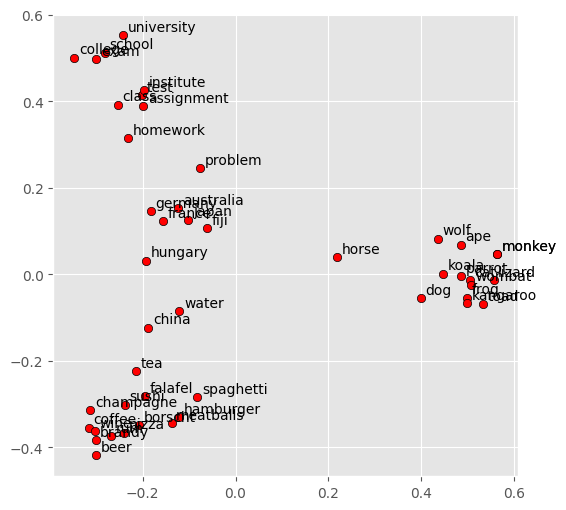

In [ ]:
%matplotlib inline

display_pca_scatterplot(model,
                        ['coffee', 'tea', 'beer', 'wine', 'brandy', 'rum', 'champagne', 'water',
                         'spaghetti', 'borscht', 'hamburger', 'pizza', 'falafel', 'sushi', 'meatballs',
                         'dog', 'horse', 'cat', 'monkey', 'parrot', 'koala', 'lizard',
                         'frog', 'toad', 'monkey', 'ape', 'kangaroo', 'wombat', 'wolf',
                         'france', 'germany', 'hungary', 'japan', 'australia', 'fiji', 'china',
                         'homework', 'assignment', 'problem', 'exam', 'test', 'class',
                         'school', 'college', 'university', 'institute'])